<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/07_multi_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 7 · Swarms and many agents · taste project*

# How does group behaviour emerge from simple individual rules?

> **In short**
>
> **How does group behaviour emerge from simple individual rules?**
>
> Give each agent a few rules about its nearest neighbours only. No agent sees the whole group, yet flocks, trails and population cycles appear. Change one local rule and the whole group changes.

## Where you'll end up

By the end you will have built:

1. **A flock of 150 birds** from three rules, written with numpy so all birds update at once.
2. **A fast way to find nearby agents** (a spatial grid), and the library version.
3. **Ants** that find food by laying and following trails.
4. **A predator–prey world** whose populations rise and fall in cycles.
5. **A cooperation tournament** from basic game theory.

Running every cell takes about two minutes.

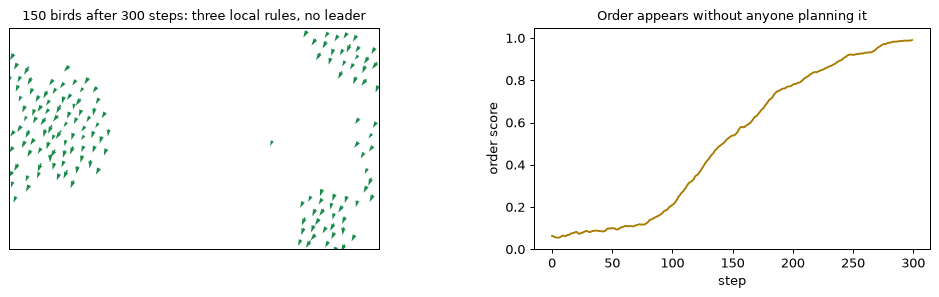

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

## 1. The problem: a flock with no leader

Thousands of starlings turn together as one shape. No bird is in charge, and each one can only see a few neighbours.
**How can the whole flock move together?**

Here is a guess, from Craig Reynolds (1987). Each bird follows three rules, using only birds within a short distance:

- **Separation:** steer away from birds that are too close.
- **Alignment:** turn toward the neighbours' average direction.
- **Cohesion:** steer toward the neighbours' centre.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

W, H = 100.0, 60.0          # world size; the edges wrap around
RADIUS = 8.0                # how far a bird can see
TOO_CLOSE = 2.5             # closer than this: move apart
SPEED = (0.6, 1.4)          # slowest and fastest allowed speed

def make_flock(n=150, seed=0):
    rng = np.random.default_rng(seed)
    pos = rng.uniform([0, 0], [W, H], size=(n, 2))
    angle = rng.uniform(0, 2 * np.pi, n)
    vel = np.stack([np.cos(angle), np.sin(angle)], axis=1)
    return pos, vel

def wrapped_offsets(pos):
    """For every pair (i, j): the arrow from bird i to bird j, taking the shortest way round the wrapped edges."""
    d = pos[None, :, :] - pos[:, None, :]            # shape (n, n, 2)
    d[..., 0] -= W * np.round(d[..., 0] / W)
    d[..., 1] -= H * np.round(d[..., 1] / H)
    return d

def step(pos, vel, separation=1.0, alignment=1.0, cohesion=1.0):
    d = wrapped_offsets(pos)
    dist = np.linalg.norm(d, axis=2)
    near = (dist < RADIUS) & (dist > 0)              # which birds each bird can see
    close = (dist < TOO_CLOSE) & (dist > 0)
    count = np.maximum(near.sum(1, keepdims=True), 1)

    centre = (d * near[..., None]).sum(1) / count                  # arrow to the neighbours' centre
    heading = (vel[None, :, :] * near[..., None]).sum(1) / count   # neighbours' average velocity
    away = -(d * close[..., None]).sum(1)                          # arrow away from birds too close

    has = near.any(1, keepdims=True)
    vel = vel + 0.05 * (separation * away + has * alignment * (heading - vel) + cohesion * 0.1 * centre)
    speed = np.linalg.norm(vel, axis=1, keepdims=True)
    vel = vel / speed * np.clip(speed, *SPEED)
    pos = (pos + vel) % [W, H]
    return pos, vel

def order(vel):
    unit = vel / np.linalg.norm(vel, axis=1, keepdims=True)
    return float(np.linalg.norm(unit.mean(0)))

pos, vel = make_flock()
print("positions:", pos.shape, "  velocities:", vel.shape, "  order score at the start:", round(order(vel), 3))

positions: (150, 2)   velocities: (150, 2)   order score at the start: 0.065


🐍 **Python notes: numpy does whole arrays at once**
- `pos` is a 150 × 2 array: one row per bird, columns x and y.
- `pos[None, :, :] - pos[:, None, :]` makes a 150 × 150 × 2 array of every bird-to-bird arrow in one line. Adding a new axis with `None` and letting numpy stretch it is **broadcasting**.
- `near = (dist < RADIUS) & (dist > 0)` is a **boolean mask**: True where bird j is within sight of bird i.
- `% [W, H]` wraps positions back into the world.

**The order score** measures how much the birds agree: make each velocity length 1, average them, and take the length. All the same way gives 1; every way at once gives about 0.

### 🤔 Predict first

Turn **alignment off** (0), keep the other two rules. **What will the birds do?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Bunch together, but point every way.** Cohesion pulls them in; nothing makes them agree on a direction. The order score stays low. Run the next cell.

</details>

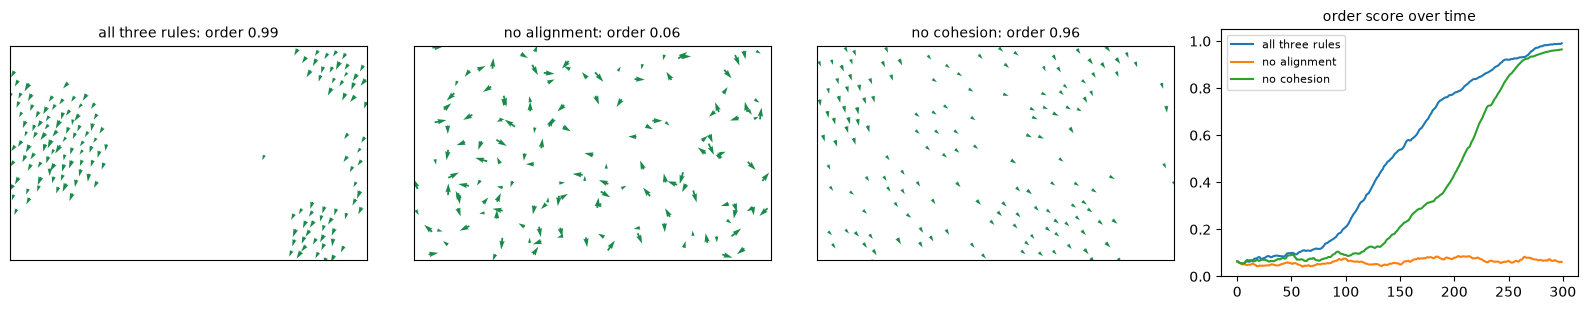

In [2]:
def run(separation, alignment, cohesion, steps=300, seed=0):
    pos, vel = make_flock(seed=seed)
    scores = []
    for _ in range(steps):
        pos, vel = step(pos, vel, separation, alignment, cohesion)
        scores.append(order(vel))
    return pos, vel, scores

settings = {"all three rules": (1, 1, 1), "no alignment": (1, 0, 1), "no cohesion": (1, 1, 0)}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (name, s) in zip(axes, settings.items()):
    p, v, sc = run(*s)
    ax.quiver(p[:, 0], p[:, 1], v[:, 0], v[:, 1], color="#188a4a", scale=40, width=0.005)
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}: order {sc[-1]:.2f}", fontsize=10)
    axes[3].plot(sc, label=name)
axes[3].set_ylim(0, 1.05); axes[3].legend(fontsize=8); axes[3].set_title("order score over time", fontsize=10)
plt.tight_layout(); plt.show()

**What you see:** with all three rules, order climbs toward 1 and the birds stream in groups. Without alignment they mill about with no shared direction.

**What it's called:** each bird is an **agent**. A pattern that exists for the group but is written in no single rule is **emergence**. These birds are **boids**.
The update for each bird, in symbols:

$$\mathbf{v} \leftarrow \mathbf{v} + 0.05\,(s\,\mathbf{F}_{\text{sep}} + a\,\mathbf{F}_{\text{align}} + c\,\mathbf{F}_{\text{coh}})$$

The velocities and forces are **vectors**: arrows with a direction and a length. Adding forces is adding arrows.

In [3]:
from matplotlib import animation
from IPython.display import HTML

pos, vel = make_flock(seed=2)
fig, ax = plt.subplots(figsize=(7, 4.2))
def frame(k):
    global pos, vel
    for _ in range(4):
        pos, vel = step(pos, vel)
    ax.clear()
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color="#188a4a", scale=40, width=0.004)
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"step {4 * (k + 1)}   order score {order(vel):.2f}")
anim = animation.FuncAnimation(fig, frame, frames=40, interval=120)
plt.close(fig)
HTML(anim.to_jshtml())

## 2. Thousands of agents: finding neighbours fast

The code above compares **every bird with every other bird**: $n^2$ distances. 150 birds is 22,500 comparisons. 5,000 birds is 25 million, every step.

Most of those pairs are far apart and can't see each other. Idea: chop the world into square cells as wide as the sight radius.
A bird's neighbours can only be in its own cell or the 8 cells around it.

In [4]:
import time
from collections import defaultdict

def neighbours_brute(pos, radius):
    d = np.linalg.norm(pos[None, :, :] - pos[:, None, :], axis=2)
    return [np.flatnonzero((d[i] < radius) & (d[i] > 0)) for i in range(len(pos))]

def neighbours_grid(pos, radius):
    cells = defaultdict(list)
    for i, (x, y) in enumerate(pos):
        cells[(int(x // radius), int(y // radius))].append(i)    # put each agent in its cell
    out = []
    for i, (x, y) in enumerate(pos):
        cx, cy = int(x // radius), int(y // radius)
        found = []
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for j in cells.get((cx + dx, cy + dy), ()):
                    if j != i and (pos[j, 0] - x) ** 2 + (pos[j, 1] - y) ** 2 < radius ** 2:
                        found.append(j)
        out.append(found)
    return out

rng = np.random.default_rng(0)
for n in (500, 2000, 4000):
    big = rng.uniform([0, 0], [400, 400], size=(n, 2))
    t0 = time.time(); a = neighbours_brute(big, 8); t1 = time.time(); b = neighbours_grid(big, 8); t2 = time.time()
    same = all(sorted(x) == sorted(y) for x, y in zip(a, b))
    print(f"{n:5d} agents: compare-everything {t1 - t0:.2f}s   grid {t2 - t1:.2f}s   same answers: {same}")

  500 agents: compare-everything 0.02s   grid 0.00s   same answers: True


 2000 agents: compare-everything 0.84s   grid 0.02s   same answers: True


 4000 agents: compare-everything 2.63s   grid 0.04s   same answers: True


🐍 `defaultdict(list)` makes a dict where a missing key starts as an empty list. `cells.get(key, ())` returns an empty tuple when a cell is empty.

**What you see:** the compare-everything time grows about 4 times when $n$ doubles (that's $O(n^2)$). The grid's grows about 2 times ($O(n)$ when agents are spread out). At a few thousand agents the grid wins.

**What it's called:** this is a **spatial grid** (or spatial hash). A **quadtree** does the same job when agents bunch up unevenly.

### The library version
`scipy` has a **k-d tree**, another structure for fast "who is near me?" questions.

In [5]:
from scipy.spatial import cKDTree
big = rng.uniform([0, 0], [400, 400], size=(4000, 2))
t0 = time.time()
tree = cKDTree(big)
lib = tree.query_ball_point(big, r=8)
lib = [[j for j in js if j != i] for i, js in enumerate(lib)]
print(f"k-d tree: {time.time() - t0:.3f}s   same answers as the grid: {all(sorted(x) == sorted(y) for x, y in zip(lib, neighbours_grid(big, 8)))}")

k-d tree: 0.010s   same answers as the grid: True


## 3. Ants: a shared memory on the ground

Ants have no map either. Each ant follows two rules:

- With no food: wander, but prefer squares with more **trail** scent.
- Carrying food: head home, and drop scent on every square you cross.

The scent fades a little each step. Trails to food get topped up; trails to nowhere fade away.

simulated in 2s


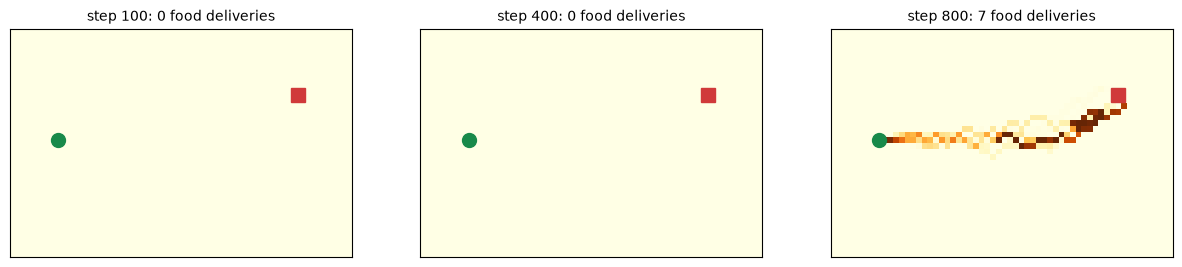

In [6]:
GW, GH = 60, 40
NEST, FOOD = np.array([8, 20]), np.array([50, 28])
MOVES8 = np.array([(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1) if (dx, dy) != (0, 0)])

def ants(n=120, steps=800, evaporate=0.02, seed=0, snapshots=(100, 400, 800)):
    rng = np.random.default_rng(seed)
    scent = np.zeros((GW, GH))
    pos = np.tile(NEST, (n, 1))
    carrying = np.zeros(n, bool)
    delivered, saved = 0, {}
    for t in range(1, steps + 1):
        for i in range(n):
            options = (pos[i] + MOVES8).clip([0, 0], [GW - 1, GH - 1])
            if carrying[i]:
                # head home: pick the move that gets closest to the nest (with a little randomness)
                d = np.linalg.norm(options - NEST, axis=1) + rng.random(8) * 0.5
                pos[i] = options[np.argmin(d)]
                scent[tuple(pos[i])] += 1.0
                if np.abs(pos[i] - NEST).max() <= 1:
                    carrying[i] = False; delivered += 1
            else:
                w = 1 + 20 * scent[options[:, 0], options[:, 1]]          # more scent, more likely
                pos[i] = options[rng.choice(8, p=w / w.sum())]
                if np.abs(pos[i] - FOOD).max() <= 2:
                    carrying[i] = True
        scent *= 1 - evaporate
        if t in snapshots:
            saved[t] = (scent.copy(), delivered)
    return saved

t0 = time.time()
saved = ants()
print(f"simulated in {time.time() - t0:.0f}s")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (t, (sc, dl)) in zip(axes, saved.items()):
    ax.imshow(sc.T, origin="lower", cmap="YlOrBr", vmax=np.percentile(sc, 99.5) + 1e-9)
    ax.plot(*NEST, "o", color="#188a4a", ms=10); ax.plot(*FOOD, "s", color="#d03a3a", ms=10)
    ax.set_title(f"step {t}: {dl} food deliveries", fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.show()

**What you see:** at first the scent is scattered. Then the ants that found food lay scent on the way home, others follow it, and a single strong trail forms between nest (green) and food (red). Deliveries speed up.

**What it's called:** agents that coordinate by changing their shared surroundings use **stigmergy**. Turned into an algorithm for finding short routes in a graph, this is **ant colony optimisation**.

## 4. Predators and prey

Rabbits wander and sometimes have offspring. Foxes wander, eat a rabbit when they land next to one, have offspring when well fed, and die if they go too long without food.
**No rule mentions population sizes.**

### 🤔 Predict first

**What do you expect the two population counts to do over time?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Rise and fall in cycles**, with foxes lagging behind rabbits: plenty of rabbits → foxes multiply → rabbits crash → foxes starve → rabbits recover. Run the next cell.

</details>

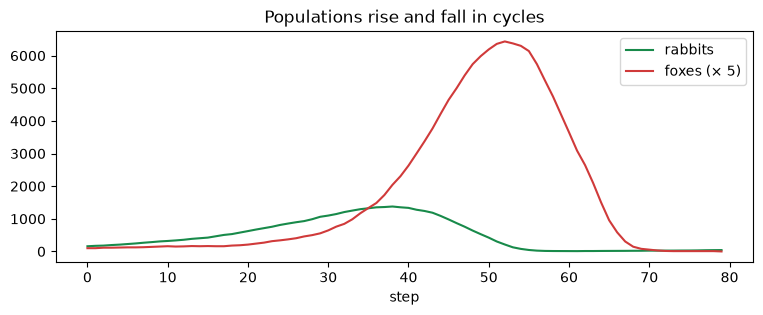

In [7]:
def predator_prey(steps=400, seed=1, size=40, rabbit_birth=0.08, fox_hunger=12):
    rng = np.random.default_rng(seed)
    rabbits = [tuple(p) for p in rng.integers(0, size, (150, 2))]
    foxes = [[tuple(p), 0] for p in rng.integers(0, size, (20, 2))]       # position, steps since eating
    history = []
    move = lambda p: ((p[0] + rng.integers(-1, 2)) % size, (p[1] + rng.integers(-1, 2)) % size)
    for _ in range(steps):
        rabbits = [move(r) for r in rabbits]
        babies = [r for r in rabbits if rng.random() < rabbit_birth]
        rabbits = (rabbits + babies)[:2000]                               # the field holds at most 2000
        where = defaultdict(list)                                        # rabbits by square, for fast lookup
        for k, r in enumerate(rabbits):
            where[r].append(k)
        eaten, new_foxes = set(), []
        for f in foxes:
            f[0] = move(f[0]); f[1] += 1
            here = [k for k in where.get(f[0], []) if k not in eaten]
            if here:
                eaten.add(here[0]); f[1] = 0
                if rng.random() < 0.5:
                    new_foxes.append([f[0], 0])
        foxes = [f for f in foxes + new_foxes if f[1] < fox_hunger]
        rabbits = [r for k, r in enumerate(rabbits) if k not in eaten]
        history.append((len(rabbits), len(foxes)))
        if not foxes or not rabbits:
            break
    return np.array(history)

hist = predator_prey()
plt.figure(figsize=(9, 3))
plt.plot(hist[:, 0], color="#188a4a", label="rabbits")
plt.plot(hist[:, 1] * 5, color="#d03a3a", label="foxes (× 5)")
plt.xlabel("step"); plt.legend(); plt.title("Populations rise and fall in cycles")
plt.show()

**What you see:** rabbit numbers climb, fox numbers follow, rabbits crash, foxes starve, and it repeats. The cycle comes from the interaction, not from any one rule.
(Exact numbers depend on the random seed; sometimes one species dies out. That fragility is real too.)

## 5. Cooperate or compete?

Two agents each choose: **cooperate** or **defect**. The points each gets depend on both choices. A table of all the outcomes is a **payoff matrix**:

| | they cooperate | they defect |
|---|---|---|
| **you cooperate** | you 3, they 3 | you 0, they 5 |
| **you defect** | you 5, they 0 | you 1, they 1 |

Look at it from your side. If they cooperate, defecting gets you 5 instead of 3. If they defect, defecting gets you 1 instead of 0.
**Defecting is better for you whatever they do**, and the same holds for them. So both defect and get 1 each, though both cooperating would give 3 each.

In [8]:
PAYOFF = {("C", "C"): (3, 3), ("C", "D"): (0, 5), ("D", "C"): (5, 0), ("D", "D"): (1, 1)}

def is_stable(a, b):
    """Neither player can do better by changing only their own choice."""
    me, them = PAYOFF[(a, b)]
    alt = "D" if a == "C" else "C"
    alt_b = "D" if b == "C" else "C"
    return PAYOFF[(alt, b)][0] <= me and PAYOFF[(a, alt_b)][1] <= them

print("stable outcomes:", [pair for pair in PAYOFF if is_stable(*pair)])

stable outcomes: [('D', 'D')]


**What it's called:** an outcome where no player gains by changing only their own choice is a **Nash equilibrium**. This game is the **prisoner's dilemma**.

Now play it **many times** with the same partner. Strategies can react to what the other did last round.

In [9]:
STRATEGIES = {
    "always cooperate": lambda mine, theirs: "C",
    "always defect": lambda mine, theirs: "D",
    "tit for tat": lambda mine, theirs: theirs[-1] if theirs else "C",       # copy their last move
    "grudger": lambda mine, theirs: "D" if "D" in theirs else "C",           # never forgive
    "random": lambda mine, theirs, r=np.random.default_rng(0): "C" if r.random() < 0.5 else "D",
}

def match(s1, s2, rounds=100):
    h1, h2, p1, p2 = [], [], 0, 0
    for _ in range(rounds):
        a, b = STRATEGIES[s1](h1, h2), STRATEGIES[s2](h2, h1)
        x, y = PAYOFF[(a, b)]
        h1.append(a); h2.append(b); p1 += x; p2 += y
    return p1, p2

totals = defaultdict(int)
names = list(STRATEGIES)
for i, s1 in enumerate(names):
    for s2 in names[i:]:
        p1, p2 = match(s1, s2)
        totals[s1] += p1
        if s1 != s2:
            totals[s2] += p2
for name, score in sorted(totals.items(), key=lambda kv: -kv[1]):
    print(f"{name:17s} {score}")

grudger           1290
tit for tat       1219
always defect     1084
always cooperate  1032
random            984


🐍 `lambda mine, theirs: ...` defines a small function inline. `sorted(..., key=lambda kv: -kv[1])` sorts by score, biggest first.

**What you see:** "always defect" is not the winner over many rounds. Strategies that start nice, punish defection, and forgive (like tit for tat) do well against a mixed field.
When agents meet again and again, cooperation can pay. Which strategies win depends on who else is in the population: an emergent effect again.

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: three birds have directions (1, 0), (0, 1) and (−1, 0). **What is the order score?**

<details><summary><b>Show the answer to exercise 1</b></summary>

Average: $((1 + 0 - 1)/3, (0 + 1 + 0)/3) = (0, 1/3)$. Length $1/3 \approx 0.33$.

</details>

### Exercise 2

Make the flock **split into separate groups** that fly in different directions and don't merge. Which rule weights, or which `RADIUS`, do it? Show the order score over time.

In [10]:
# your experiment here

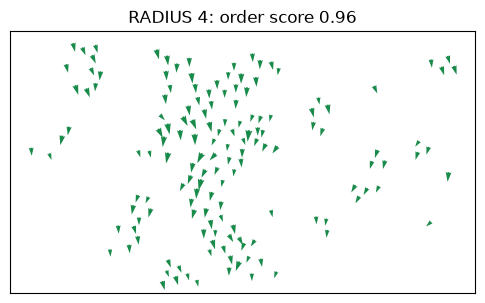

In [11]:
#@title Solution to exercise 2 (double-click to show)
RADIUS = 4.0            # birds see less, so distant groups never notice each other
p, v, sc = run(1, 1, 1, steps=300)
plt.figure(figsize=(6, 3.4))
plt.quiver(p[:, 0], p[:, 1], v[:, 0], v[:, 1], color="#188a4a", scale=40, width=0.005)
plt.title(f"RADIUS 4: order score {sc[-1]:.2f}"); plt.xticks([]); plt.yticks([]); plt.show()
RADIUS = 8.0            # put it back
# Each group aligns internally, but groups can't see each other, so the overall order score stays well below 1.

### Exercise 3

In the ant world, set `evaporate=0.0` (scent never fades) and then `evaporate=0.2`. **How many deliveries happen in each case, and why?**

In [12]:
# your experiment here

In [13]:
#@title Solution to exercise 3 (double-click to show)
for ev in (0.0, 0.02, 0.2):
    s = ants(evaporate=ev, snapshots=(800,))
    print(f"evaporate {ev}: {s[800][1]} deliveries")
# No fading: old wandering scent never disappears, so ants are pulled in many directions.
# Fast fading: trails vanish before other ants can follow them. A middle value works best.

evaporate 0.0: 6 deliveries


evaporate 0.02: 7 deliveries


evaporate 0.2: 5 deliveries


## Recognition cues

- When you see **many simple agents and one group outcome** in a problem, think **simulate the local rules and watch (emergence)**.
- When you see **"each agent needs the agents near it, for thousands of agents"** in a problem, think **a spatial grid, quadtree or k-d tree**.
- When you see **"each agent's best choice depends on the others' choices"** in a problem, think **a payoff matrix: look for Nash equilibria**.
- When you see **the same calculation for every agent** in a problem, think **numpy arrays: update all agents at once**.

## Try changing this

1. **Add a predator to the flock.** Make one boid that steers toward the nearest bird, and make birds steer away from it. Does the flock split?
2. **Change one rule.** In the predator–prey world, set `fox_hunger=6`. Do the cycles survive?
3. **A new strategy.** Add "tit for two tats" (defect only after two defections in a row) to the tournament. Where does it rank?

## Open research questions

People are working on these right now:

- How do AI agents learn to cooperate or negotiate?
- How do we predict what a whole system will do?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Swarms and many agents** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Craig Reynolds' original boids page: https://www.red3d.com/cwr/boids/
- At Monash: FIT5226 Multi-agent systems and collective behaviour.